In [3]:
from tensorflow.examples.tutorials.mnist import input_data
import tensorflow as tf
import numpy as np
import os

# 载入数据集
mnist = input_data.read_data_sets("MNIST_data", one_hot=True)
X_train, y_train = mnist.train.images, mnist.train.labels # 训练集 (55000, 784)
X_test, y_test = mnist.test.images, mnist.test.labels # 测试集 (10000, 784)
X_valid, y_valid = mnist.validation.images, mnist.validation.labels # 验证集 (5000, 784)
print(X_valid.shape)
print(X_train[0])
# 使用NVIDIA-GPU显卡
tf.device('/gpu:1')

Extracting MNIST_data\train-images-idx3-ubyte.gz
Extracting MNIST_data\train-labels-idx1-ubyte.gz
Extracting MNIST_data\t10k-images-idx3-ubyte.gz
Extracting MNIST_data\t10k-labels-idx1-ubyte.gz
(5000, 784)
[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.  

In [53]:
n_epochs = 200  # 训练总轮次：200
batch_size = 100  # 每个批次大小
l2 = 1e-5  # l2
# 计算一共有多少个批次,即每轮训练的批次
n_batch = mnist.train.num_examples // batch_size  # 总样本数整除每个批次大小
# adam优化器参数设置
# lr = 0.001  # 学习速率
beta1=0.9
beta2=0.999

# 定义两个placeholder
x = tf.placeholder(tf.float32, [None, 784])  # 占位符，x用作输入变量
y = tf.placeholder(tf.float32, [None, 10])  # 占位符，y代表真实标签
keep_prob = tf.placeholder(tf.float32)  # 定义使用的神经元占该层神经元总数的比例
lr = tf.Variable(0.002, dtype=tf.float32)  # 学习速率

#创建一个简单的神经网络
# 定义网络参数
W1 = tf.Variable(tf.truncated_normal([784,400],stddev=0.1))  # 初始化权重W1，标准差为0.1，均值默认为0
b1 = tf.Variable(tf.zeros([400])+0.1)  # 初始化偏置b1
L1 = tf.nn.sigmoid(tf.matmul(x, W1)+b1)  # 神经网络前向传播过程，以sigmoid函数激活
# drop层
L1_drop = tf.nn.dropout(L1,keep_prob)  # 随机舍弃部分神经元，剩余部分占比为keep_prob

W2 = tf.Variable(tf.truncated_normal([400,200],stddev=0.1))
b2 = tf.Variable(tf.zeros([200])+0.1)
L2 = tf.nn.sigmoid(tf.matmul(L1_drop, W2)+b2) # 神经网络前向传播过程，以sigmoid函数激活
L2_drop = tf.nn.dropout(L2,keep_prob)

W3 = tf.Variable(tf.truncated_normal([200,10],stddev=0.1))
b3 = tf.Variable(tf.zeros([10])+0.1)
prediction = tf.nn.softmax(tf.matmul(L2_drop,W3) + b3)  # softmax以概率输出结果


# 定义代价函数和反向传播算法
# 交叉熵代价函数
loss = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits_v2(labels=y,logits=prediction))
cost = loss + tf.contrib.layers.l2_regularizer(l2)(W1) + tf.contrib.layers.l2_regularizer(l2)(W2) + tf.contrib.layers.l2_regularizer(l2)(W3)  # 添加l2正则化，对权重规整
opt = tf.train.AdamOptimizer(lr, beta1, beta2).minimize(cost)  # Adam优化器最小化损失函数，反向传播更新权重

init = tf.global_variables_initializer()

# one_hot编码结果存放到一个布尔型表中
correct_prediction = tf.equal(tf.argmax(y, 1), tf.argmax(prediction, 1))  # 两者后验概率完全一致则预测正确
# 求准确率
accuracy = tf.reduce_mean(tf.cast(correct_prediction, tf.float32))

saver = tf.train.Saver()  # 存储函数初始化

model_dir = 'checkpoints'  # 模型存储位置
if not os.path.exists(model_dir):
    os.makedirs(model_dir)  # 给位置不存在则创建

# 创建会话运行tensorflow程序
with tf.Session() as sess:
    sess.run(init)
    values = np.ones((5,200),float)  # 定义一个4*200的二维数组
    learning_rate = np.zeros([200])
    for epoch in range(n_epochs):
        sess.run(tf.assign(lr, 0.001 * (0.99 ** epoch)))  # 每个轮次学习速率乘以0.98
        for batch in range(n_batch):
            batch_xs,batch_ys = mnist.train.next_batch(batch_size,shuffle=True)  # 打乱顺序，取下一个batch的训练数据和标签
            sess.run(opt, feed_dict={x:batch_xs, y:batch_ys,keep_prob:1})  # 喂入数据训练神经网络，反向传播更新权重
        
        epoch =int(epoch)
        learning_rate[epoch] = sess.run(lr)
        values[0,epoch] = sess.run(cost, feed_dict={x:X_valid, y:y_valid, keep_prob:1})  # 验证集损失
        values[1,epoch]  = sess.run(cost, feed_dict={x:X_train, y:y_train, keep_prob:1})  # 训练集损失
        values[2,epoch]  = sess.run(accuracy, feed_dict={x:X_valid, y:y_valid, keep_prob:1})  # 验证集准确度
        values[3,epoch]  = sess.run(accuracy, feed_dict={x:X_train, y:y_train, keep_prob:1})  # 训练集准确度
        values[4,epoch]  = sess.run(accuracy, feed_dict={x:X_test, y:y_test, keep_prob:1})  # 测试集准确度
        if epoch % 5 == 0:
            print("Iter: " + str(epoch) + " ,Validation Accuracy: " + str('%.5f' % values[2,epoch])+ " ,Training Accuracy: " + str('%.5f' % values[3,epoch])+ " ,Testing Accuracy: " + str('%.5f' % values[4,epoch])+" ,Learning Rate: "+str('%.5f' % learning_rate[epoch]))
#     saver.save(sess, model_dir + '/mlp_mnist_model.ckpt')

Iter: 0 ,Validation Accuracy: 0.90740 ,Training Accuracy: 0.90215 ,Testing Accuracy: 0.90580 ,Learning Rate: 0.00100
Iter: 5 ,Validation Accuracy: 0.96960 ,Training Accuracy: 0.97071 ,Testing Accuracy: 0.96280 ,Learning Rate: 0.00095
Iter: 10 ,Validation Accuracy: 0.97580 ,Training Accuracy: 0.98322 ,Testing Accuracy: 0.97260 ,Learning Rate: 0.00090
Iter: 15 ,Validation Accuracy: 0.97860 ,Training Accuracy: 0.98836 ,Testing Accuracy: 0.97630 ,Learning Rate: 0.00086
Iter: 20 ,Validation Accuracy: 0.97940 ,Training Accuracy: 0.99125 ,Testing Accuracy: 0.97800 ,Learning Rate: 0.00082
Iter: 25 ,Validation Accuracy: 0.98260 ,Training Accuracy: 0.99345 ,Testing Accuracy: 0.97990 ,Learning Rate: 0.00078
Iter: 30 ,Validation Accuracy: 0.98260 ,Training Accuracy: 0.99464 ,Testing Accuracy: 0.98100 ,Learning Rate: 0.00074
Iter: 35 ,Validation Accuracy: 0.98080 ,Training Accuracy: 0.99515 ,Testing Accuracy: 0.98110 ,Learning Rate: 0.00070
Iter: 40 ,Validation Accuracy: 0.98160 ,Training Accuracy:

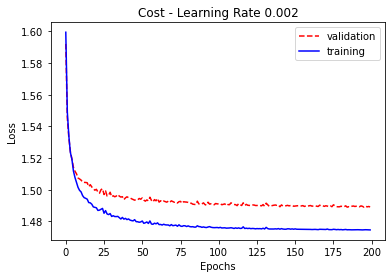

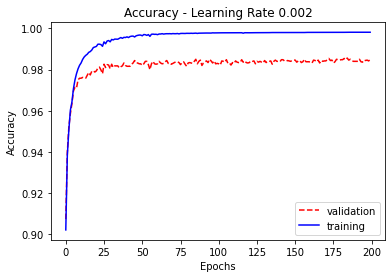

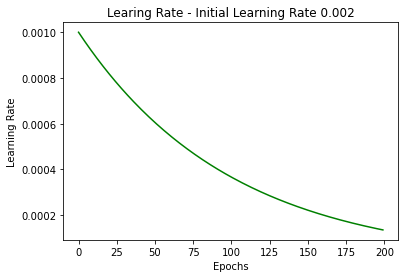

In [54]:
import matplotlib.pyplot as plt
import numpy as np


epochs = np.arange(0,200,1)

# ax1 = plt.subplot(1, 2, 1)
plt.plot(epochs, values[0], 'r--', label="validation")
plt.plot(epochs, values[1], 'b-', label="training")
plt.title('Cost - Learning Rate 0.002')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="upper right")  # 显示位置
plt.show()

# ax2 = plt.subplot(1, 2, 2)
plt.plot(epochs, values[2], 'r--', label="validation")
plt.plot(epochs, values[3], 'b-', label="training")
plt.title('Accuracy - Learning Rate 0.002')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(epochs, learning_rate, 'g-', label="lr")
plt.title('Learing Rate - Initial Learning Rate 0.002')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.show()

In [55]:
n_epochs = 200  # 训练总轮次：200
batch_size = 100  # 每个批次大小
l2 = 2.5e-4  # l2
# 计算一共有多少个批次,即每轮训练的批次
n_batch = mnist.train.num_examples // batch_size  # 总样本数整除每个批次大小
# adam优化器参数设置
# lr = 0.001  # 学习速率
beta1=0.9
beta2=0.999

# 定义两个placeholder
x = tf.placeholder(tf.float32, [None, 784])  # 占位符，x用作输入变量
y = tf.placeholder(tf.float32, [None, 10])  # 占位符，y代表真实标签
keep_prob = tf.placeholder(tf.float32)  # 定义使用的神经元占该层神经元总数的比例
lr = tf.Variable(0.002, dtype=tf.float32)  # 学习速率

#创建一个简单的神经网络
# 定义网络参数
W1 = tf.Variable(tf.truncated_normal([784,400],stddev=0.1))  # 初始化权重W1，标准差为0.1，均值默认为0
b1 = tf.Variable(tf.zeros([400])+0.1)  # 初始化偏置b1
L1 = tf.nn.sigmoid(tf.matmul(x, W1)+b1)  # 神经网络前向传播过程，以sigmoid函数激活
# drop层
L1_drop = tf.nn.dropout(L1,keep_prob)  # 随机舍弃部分神经元，剩余部分占比为keep_prob

W2 = tf.Variable(tf.truncated_normal([400,200],stddev=0.1))
b2 = tf.Variable(tf.zeros([200])+0.1)
L2 = tf.nn.sigmoid(tf.matmul(L1_drop, W2)+b2) # 神经网络前向传播过程，以sigmoid函数激活
L2_drop = tf.nn.dropout(L2,keep_prob)

W3 = tf.Variable(tf.truncated_normal([200,10],stddev=0.1))
b3 = tf.Variable(tf.zeros([10])+0.1)
prediction = tf.nn.softmax(tf.matmul(L2_drop,W3) + b3)  # softmax以概率输出结果


# 定义代价函数和反向传播算法
# 交叉熵代价函数
loss = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits_v2(labels=y,logits=prediction))
cost = loss + tf.contrib.layers.l2_regularizer(l2)(W1) + tf.contrib.layers.l2_regularizer(l2)(W2) + tf.contrib.layers.l2_regularizer(l2)(W3)  # 添加l2正则化，对权重规整
opt = tf.train.AdamOptimizer(lr, beta1, beta2).minimize(cost)  # Adam优化器最小化损失函数，反向传播更新权重

init = tf.global_variables_initializer()

# one_hot编码结果存放到一个布尔型表中
correct_prediction = tf.equal(tf.argmax(y, 1), tf.argmax(prediction, 1))  # 两者后验概率完全一致则预测正确
# 求准确率
accuracy = tf.reduce_mean(tf.cast(correct_prediction, tf.float32))

saver = tf.train.Saver()  # 存储函数初始化

model_dir = 'checkpoints'  # 模型存储位置
if not os.path.exists(model_dir):
    os.makedirs(model_dir)  # 给位置不存在则创建

# 创建会话运行tensorflow程序
with tf.Session() as sess:
    sess.run(init)
    values = np.ones((5,200),float)  # 定义一个4*200的二维数组
    learning_rate = np.zeros([200])
    for epoch in range(n_epochs):
        sess.run(tf.assign(lr, 0.001 * (0.99 ** epoch)))  # 每个轮次学习速率乘以0.98
        for batch in range(n_batch):
            batch_xs,batch_ys = mnist.train.next_batch(batch_size,shuffle=True)  # 打乱顺序，取下一个batch的训练数据和标签
            sess.run(opt, feed_dict={x:batch_xs, y:batch_ys,keep_prob:1})  # 喂入数据训练神经网络，反向传播更新权重
        
        epoch =int(epoch)
        learning_rate[epoch] = sess.run(lr)
        values[0,epoch] = sess.run(cost, feed_dict={x:X_valid, y:y_valid, keep_prob:1})  # 验证集损失
        values[1,epoch]  = sess.run(cost, feed_dict={x:X_train, y:y_train, keep_prob:1})  # 训练集损失
        values[2,epoch]  = sess.run(accuracy, feed_dict={x:X_valid, y:y_valid, keep_prob:1})  # 验证集准确度
        values[3,epoch]  = sess.run(accuracy, feed_dict={x:X_train, y:y_train, keep_prob:1})  # 训练集准确度
        values[4,epoch]  = sess.run(accuracy, feed_dict={x:X_test, y:y_test, keep_prob:1})  # 测试集准确度
        if epoch % 5 == 0:
            print("Iter: " + str(epoch) + " ,Validation Accuracy: " + str('%.5f' % values[2,epoch])+ " ,Training Accuracy: " + str('%.5f' % values[3,epoch])+ " ,Testing Accuracy: " + str('%.5f' % values[4,epoch])+" ,Learning Rate: "+str('%.5f' % learning_rate[epoch]))
#     saver.save(sess, model_dir + '/mlp_mnist_model.ckpt')

Iter: 0 ,Validation Accuracy: 0.82840 ,Training Accuracy: 0.82538 ,Testing Accuracy: 0.82540 ,Learning Rate: 0.00100
Iter: 5 ,Validation Accuracy: 0.93040 ,Training Accuracy: 0.92524 ,Testing Accuracy: 0.92970 ,Learning Rate: 0.00095
Iter: 10 ,Validation Accuracy: 0.94800 ,Training Accuracy: 0.94491 ,Testing Accuracy: 0.94500 ,Learning Rate: 0.00090
Iter: 15 ,Validation Accuracy: 0.94760 ,Training Accuracy: 0.94538 ,Testing Accuracy: 0.94590 ,Learning Rate: 0.00086
Iter: 20 ,Validation Accuracy: 0.95320 ,Training Accuracy: 0.95178 ,Testing Accuracy: 0.94970 ,Learning Rate: 0.00082
Iter: 25 ,Validation Accuracy: 0.95900 ,Training Accuracy: 0.95544 ,Testing Accuracy: 0.95170 ,Learning Rate: 0.00078
Iter: 30 ,Validation Accuracy: 0.95360 ,Training Accuracy: 0.95445 ,Testing Accuracy: 0.95270 ,Learning Rate: 0.00074
Iter: 35 ,Validation Accuracy: 0.95960 ,Training Accuracy: 0.95865 ,Testing Accuracy: 0.95650 ,Learning Rate: 0.00070
Iter: 40 ,Validation Accuracy: 0.95880 ,Training Accuracy:

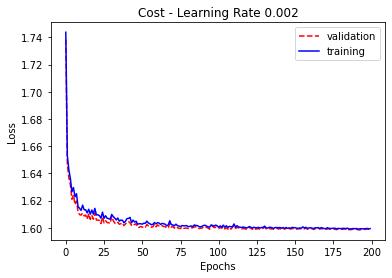

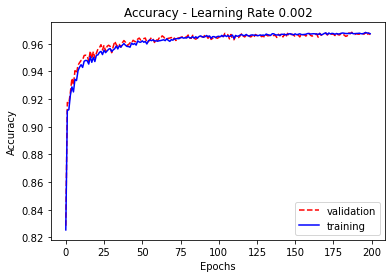

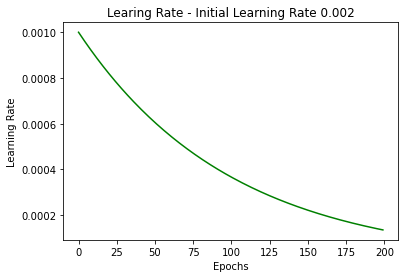

In [56]:
import matplotlib.pyplot as plt
import numpy as np


epochs = np.arange(0,200,1)

# ax1 = plt.subplot(1, 2, 1)
plt.plot(epochs, values[0], 'r--', label="validation")
plt.plot(epochs, values[1], 'b-', label="training")
plt.title('Cost - Learning Rate 0.002')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="upper right")  # 显示位置
plt.show()

# ax2 = plt.subplot(1, 2, 2)
plt.plot(epochs, values[2], 'r--', label="validation")
plt.plot(epochs, values[3], 'b-', label="training")
plt.title('Accuracy - Learning Rate 0.002')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(epochs, learning_rate, 'g-', label="lr")
plt.title('Learing Rate - Initial Learning Rate 0.002')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.show()

In [74]:
n_epochs = 200  # 训练总轮次：200
batch_size = 100  # 每个批次大小
l2 =4e-5  # l2
# 计算一共有多少个批次,即每轮训练的批次
n_batch = mnist.train.num_examples // batch_size  # 总样本数整除每个批次大小
# adam优化器参数设置
# lr = 0.001  # 学习速率
beta1=0.9
beta2=0.999

# 定义两个placeholder
x = tf.placeholder(tf.float32, [None, 784])  # 占位符，x用作输入变量
y = tf.placeholder(tf.float32, [None, 10])  # 占位符，y代表真实标签
keep_prob = tf.placeholder(tf.float32)  # 定义使用的神经元占该层神经元总数的比例
lr = tf.Variable(0.001, dtype=tf.float32)  # 学习速率

#创建一个简单的神经网络
# 定义网络参数
W1 = tf.Variable(tf.truncated_normal([784,200],stddev=0.1))  # 初始化权重W1，标准差为0.1，均值默认为0
b1 = tf.Variable(tf.zeros([200])+0.1)  # 初始化偏置b1
L1 = tf.nn.sigmoid(tf.matmul(x, W1)+b1)  # 神经网络前向传播过程，以sigmoid函数激活
# drop层
L1_drop = tf.nn.dropout(L1,keep_prob)  # 随机舍弃部分神经元，剩余部分占比为keep_prob

W2 = tf.Variable(tf.truncated_normal([200,100],stddev=0.1))
b2 = tf.Variable(tf.zeros([100])+0.1)
L2 = tf.nn.sigmoid(tf.matmul(L1_drop, W2)+b2) # 神经网络前向传播过程，以sigmoid函数激活
# drop层
L2_drop = tf.nn.dropout(L2,keep_prob)

W3 = tf.Variable(tf.truncated_normal([100,10],stddev=0.1))
b3 = tf.Variable(tf.zeros([10])+0.1)
prediction = tf.nn.softmax(tf.matmul(L2_drop,W3) + b3)  # softmax以概率输出结果

# 定义代价函数和反向传播算法
# 交叉熵代价函数
loss = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits_v2(labels=y,logits=prediction))
cost = loss + tf.contrib.layers.l2_regularizer(l2)(W1) + tf.contrib.layers.l2_regularizer(l2)(W2) + tf.contrib.layers.l2_regularizer(l2)(W3)  # 添加l2正则化，对权重规整
opt = tf.train.AdamOptimizer(lr, beta1, beta2).minimize(cost)  # Adam优化器最小化损失函数，反向传播更新权重

init = tf.global_variables_initializer()

# one_hot编码结果存放到一个布尔型表中
correct_prediction = tf.equal(tf.argmax(y, 1), tf.argmax(prediction, 1))  # 两者后验概率完全一致则预测正确
# 求准确率
accuracy = tf.reduce_mean(tf.cast(correct_prediction, tf.float32))

saver = tf.train.Saver()  # 存储函数初始化

model_dir = 'checkpoints'  # 模型存储位置
if not os.path.exists(model_dir):
    os.makedirs(model_dir)  # 给位置不存在则创建

# 创建会话运行tensorflow程序
with tf.Session() as sess:
    sess.run(init)
    values = np.ones((5,200),float)  # 定义一个4*200的二维数组
    learning_rate = np.zeros([200])
    for epoch in range(n_epochs):
        sess.run(tf.assign(lr, 0.002 * (0.96 ** epoch)))  # 每个轮次学习速率乘以0.98
        for batch in range(n_batch):
            batch_xs,batch_ys = mnist.train.next_batch(batch_size,shuffle=True)  # 打乱顺序，取下一个batch的训练数据和标签
            sess.run(opt, feed_dict={x:batch_xs, y:batch_ys,keep_prob:1.0})  # 喂入数据训练神经网络，反向传播更新权重
        
        epoch =int(epoch)
        learning_rate[epoch] = sess.run(lr)
        values[0,epoch] = sess.run(cost, feed_dict={x:X_valid, y:y_valid, keep_prob:1})  # 验证集损失
        values[1,epoch]  = sess.run(cost, feed_dict={x:X_train, y:y_train, keep_prob:1})  # 训练集损失
        values[2,epoch]  = sess.run(accuracy, feed_dict={x:X_valid, y:y_valid, keep_prob:1})  # 验证集准确度
        values[3,epoch]  = sess.run(accuracy, feed_dict={x:X_train, y:y_train, keep_prob:1})  # 训练集准确度
        values[4,epoch]  = sess.run(accuracy, feed_dict={x:X_test, y:y_test, keep_prob:1})  # 测试集准确度
        if epoch % 5 == 0:
            print("Iter: " + str(epoch) + " ,Validation Accuracy: " + str('%.5f' % values[2,epoch])+ " ,Training Accuracy: " + str('%.5f' % values[3,epoch])+ " ,Testing Accuracy: " + str('%.5f' % values[4,epoch])+" ,Learning Rate: "+str('%.5f' % learning_rate[epoch]))
#     saver.save(sess, model_dir + '/mlp_mnist_model.ckpt')

Iter: 0 ,Validation Accuracy: 0.92940 ,Training Accuracy: 0.92585 ,Testing Accuracy: 0.92650 ,Learning Rate: 0.00200
Iter: 5 ,Validation Accuracy: 0.96900 ,Training Accuracy: 0.97265 ,Testing Accuracy: 0.96510 ,Learning Rate: 0.00163
Iter: 10 ,Validation Accuracy: 0.97440 ,Training Accuracy: 0.98329 ,Testing Accuracy: 0.97260 ,Learning Rate: 0.00133
Iter: 15 ,Validation Accuracy: 0.97760 ,Training Accuracy: 0.98540 ,Testing Accuracy: 0.97480 ,Learning Rate: 0.00108
Iter: 20 ,Validation Accuracy: 0.97820 ,Training Accuracy: 0.98927 ,Testing Accuracy: 0.97690 ,Learning Rate: 0.00088
Iter: 25 ,Validation Accuracy: 0.97800 ,Training Accuracy: 0.99029 ,Testing Accuracy: 0.97830 ,Learning Rate: 0.00072
Iter: 30 ,Validation Accuracy: 0.97920 ,Training Accuracy: 0.99165 ,Testing Accuracy: 0.97690 ,Learning Rate: 0.00059
Iter: 35 ,Validation Accuracy: 0.98060 ,Training Accuracy: 0.99269 ,Testing Accuracy: 0.97960 ,Learning Rate: 0.00048
Iter: 40 ,Validation Accuracy: 0.98080 ,Training Accuracy:

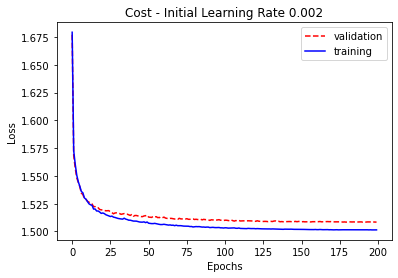

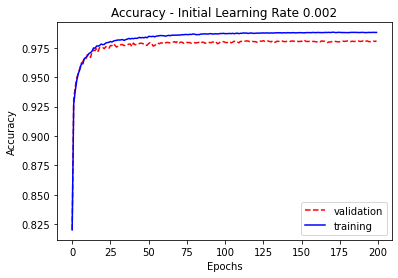

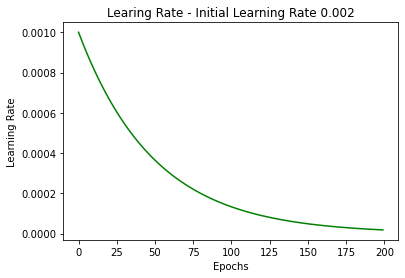

In [67]:
import matplotlib.pyplot as plt
import numpy as np


epochs = np.arange(0,200,1)

# ax1 = plt.subplot(1, 2, 1)
plt.plot(epochs, values[0], 'r--', label="validation")
plt.plot(epochs, values[1], 'b-', label="training")
plt.title('Cost - Initial Learning Rate 0.002')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="upper right")  # 显示位置
plt.show()

# ax2 = plt.subplot(1, 2, 2)
plt.plot(epochs, values[2], 'r--', label="validation")
plt.plot(epochs, values[3], 'b-', label="training")
plt.title('Accuracy - Initial Learning Rate 0.002')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(epochs, learning_rate, 'g-', label="lr")
plt.title('Learing Rate - Initial Learning Rate 0.002')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.show()

In [ ]:
n_epochs = 200  # 训练总轮次：200
batch_size = 100  # 每个批次大小
l2 = 2e-5  # l2
# 计算一共有多少个批次,即每轮训练的批次
n_batch = mnist.train.num_examples // batch_size  # 总样本数整除每个批次大小
# adam优化器参数设置
# lr = 0.001  # 学习速率
beta1=0.9
beta2=0.999

# 定义两个placeholder
x = tf.placeholder(tf.float32, [None, 784])  # 占位符，x用作输入变量
y = tf.placeholder(tf.float32, [None, 10])  # 占位符，y代表真实标签
keep_prob = tf.placeholder(tf.float32)  # 定义使用的神经元占该层神经元总数的比例
lr = tf.Variable(0.001, dtype=tf.float32)  # 学习速率

#创建一个简单的神经网络
# 定义网络参数
W1 = tf.Variable(tf.truncated_normal([784,600],stddev=0.1))  # 初始化权重W1，标准差为0.1，均值默认为0
b1 = tf.Variable(tf.zeros([600])+0.1)  # 初始化偏置b1
L1 = tf.nn.sigmoid(tf.matmul(x, W1)+b1)  # 神经网络前向传播过程，以sigmoid函数激活
# drop层
L1_drop = tf.nn.dropout(L1,keep_prob)  # 随机舍弃部分神经元，剩余部分占比为keep_prob

W2 = tf.Variable(tf.truncated_normal([600,300],stddev=0.1))
b2 = tf.Variable(tf.zeros([300])+0.1)
L2 = tf.nn.sigmoid(tf.matmul(L1_drop, W2)+b2) # 神经网络前向传播过程，以sigmoid函数激活
L2_drop = tf.nn.dropout(L2,keep_prob)

W3 = tf.Variable(tf.truncated_normal([300,10],stddev=0.1))
b3 = tf.Variable(tf.zeros([10])+0.1)
prediction = tf.nn.softmax(tf.matmul(L2_drop,W3) + b3)  # softmax以概率输出结果

# 定义代价函数和反向传播算法
# 交叉熵代价函数
loss = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits_v2(labels=y,logits=prediction))
cost = loss + tf.contrib.layers.l2_regularizer(l2)(W1) + tf.contrib.layers.l2_regularizer(l2)(W2) + tf.contrib.layers.l2_regularizer(l2)(W3)  # 添加l2正则化，对权重规整
opt = tf.train.AdamOptimizer(lr, beta1, beta2).minimize(cost)  # Adam优化器最小化损失函数，反向传播更新权重

init = tf.global_variables_initializer()

# one_hot编码结果存放到一个布尔型表中
correct_prediction = tf.equal(tf.argmax(y, 1), tf.argmax(prediction, 1))  # 两者后验概率完全一致则预测正确
# 求准确率
accuracy = tf.reduce_mean(tf.cast(correct_prediction, tf.float32))

saver = tf.train.Saver()  # 存储函数初始化

model_dir = 'checkpoints'  # 模型存储位置
if not os.path.exists(model_dir):
    os.makedirs(model_dir)  # 给位置不存在则创建

# 创建会话运行tensorflow程序
with tf.Session() as sess:
    sess.run(init)
    values = np.ones((5,200),float)  # 定义一个4*200的二维数组
    learning_rate = np.zeros([200])
    for epoch in range(n_epochs):
        sess.run(tf.assign(lr, 0.001 * (0.98 ** epoch)))  # 每个轮次学习速率乘以0.98
        for batch in range(n_batch):
            batch_xs,batch_ys = mnist.train.next_batch(batch_size,shuffle=True)  # 打乱顺序，取下一个batch的训练数据和标签
            sess.run(opt, feed_dict={x:batch_xs, y:batch_ys,keep_prob:0.5})  # 喂入数据训练神经网络，反向传播更新权重
        
        epoch =int(epoch)
        learning_rate[epoch] = sess.run(lr)
        values[0,epoch] = sess.run(cost, feed_dict={x:X_valid, y:y_valid, keep_prob:1})  # 验证集损失
        values[1,epoch]  = sess.run(cost, feed_dict={x:X_train, y:y_train, keep_prob:1})  # 训练集损失
        values[2,epoch]  = sess.run(accuracy, feed_dict={x:X_valid, y:y_valid, keep_prob:1})  # 验证集准确度
        values[3,epoch]  = sess.run(accuracy, feed_dict={x:X_train, y:y_train, keep_prob:1})  # 训练集准确度
        values[4,epoch]  = sess.run(accuracy, feed_dict={x:X_test, y:y_test, keep_prob:1})  # 测试集准确度
        if epoch % 5 == 0:
            print("Iter: " + str(epoch) + " ,Validation Accuracy: " + str('%.5f' % values[2,epoch])+ " ,Training Accuracy: " + str('%.5f' % values[3,epoch])+ " ,Testing Accuracy: " + str('%.5f' % values[4,epoch])+" ,Learning Rate: "+str('%.5f' % learning_rate[epoch]))
#     saver.save(sess, model_dir + '/mlp_mnist_model.ckpt')

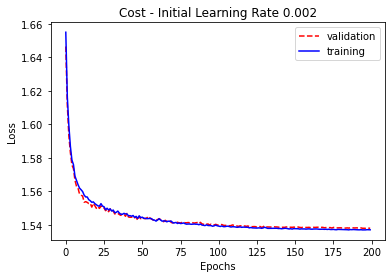

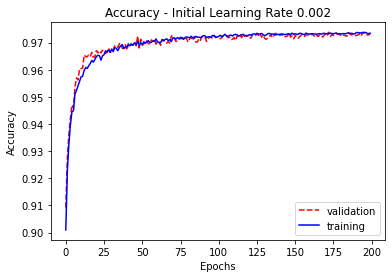

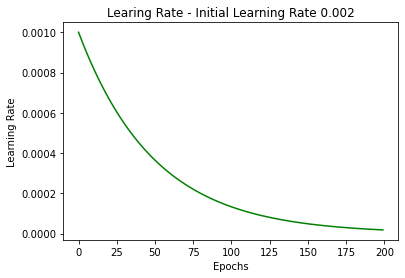

In [73]:
import matplotlib.pyplot as plt
import numpy as np


epochs = np.arange(0,200,1)

# ax1 = plt.subplot(1, 2, 1)
plt.plot(epochs, values[0], 'r--', label="validation")
plt.plot(epochs, values[1], 'b-', label="training")
plt.title('Cost - Initial Learning Rate 0.002')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc="upper right")  # 显示位置
plt.show()

# ax2 = plt.subplot(1, 2, 2)
plt.plot(epochs, values[2], 'r--', label="validation")
plt.plot(epochs, values[3], 'b-', label="training")
plt.title('Accuracy - Initial Learning Rate 0.002')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(epochs, learning_rate, 'g-', label="lr")
plt.title('Learing Rate - Initial Learning Rate 0.002')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate')
plt.show()